<a href="https://colab.research.google.com/github/Shriram28Baskar/Projects/blob/main/Project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score

PIMA Diabetes Dataset is being used here


In [2]:
# We load the diabetes dataset to the pandas dataframe
diabetes_dataset = pd.read_csv('/content/diabetes.csv')

In [3]:
# .head() prints the first 5 rows of the dataset
diabetes_dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# .shape() prints the number of rows and columns of the dataset
diabetes_dataset.shape

(768, 9)

In [5]:
# .describe() prints the stastical measure of the data
diabetes_dataset.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
# .describe() prints the stastical measure of the data
diabetes_dataset.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
# To count how many patients in the dataset are diabetic (1) and non-diabetic (0).
diabetes_dataset['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


In [8]:
# To calculate the average value of each feature separately for diabetic (1) and non-diabetic (0) patients
diabetes_dataset.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


In [9]:
# Labels are the correct answers (target values) that the model tries to predict.
# Data refers to the information or values used to train and test a model.
X = diabetes_dataset.drop(columns = 'Outcome', axis=1)
Y = diabetes_dataset['Outcome']

In [10]:
print(X)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


In [11]:
print(Y)

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64


Data Standardization (It's a preprocessing technique used in Machine Learning to transform data so that features have a mean of 0 and a standard deviation of 1)


In [12]:
scaler = StandardScaler()
# It creates an object that standardizes the dataset features by converting them to a common scale (mean = 0 and standard deviation = 1)

In [13]:
scaler.fit(X)
# It calculates the mean and standard deviation of each feature in X so the data can be standardized later.

StandardScaler()

In [15]:
standardized_data = scaler.transform(X)
# It applies the calculated scaling (using mean and standard deviation) to transform the dataset X into standardized values

In [16]:
print(standardized_data)

[[ 0.63994726  0.84832379  0.14964075 ...  0.20401277  0.46849198
   1.4259954 ]
 [-0.84488505 -1.12339636 -0.16054575 ... -0.68442195 -0.36506078
  -0.19067191]
 [ 1.23388019  1.94372388 -0.26394125 ... -1.10325546  0.60439732
  -0.10558415]
 ...
 [ 0.3429808   0.00330087  0.14964075 ... -0.73518964 -0.68519336
  -0.27575966]
 [-0.84488505  0.1597866  -0.47073225 ... -0.24020459 -0.37110101
   1.17073215]
 [-0.84488505 -0.8730192   0.04624525 ... -0.20212881 -0.47378505
  -0.87137393]]


In [17]:
X = standardized_data
Y = diabetes_dataset['Outcome']

In [19]:
print(X)

[[ 0.63994726  0.84832379  0.14964075 ...  0.20401277  0.46849198
   1.4259954 ]
 [-0.84488505 -1.12339636 -0.16054575 ... -0.68442195 -0.36506078
  -0.19067191]
 [ 1.23388019  1.94372388 -0.26394125 ... -1.10325546  0.60439732
  -0.10558415]
 ...
 [ 0.3429808   0.00330087  0.14964075 ... -0.73518964 -0.68519336
  -0.27575966]
 [-0.84488505  0.1597866  -0.47073225 ... -0.24020459 -0.37110101
   1.17073215]
 [-0.84488505 -0.8730192   0.04624525 ... -0.20212881 -0.47378505
  -0.87137393]]


In [20]:
print(Y)

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64


Train Test Split (It splits the dataset so the model can learn from one part (training set) and be evaluated on another part (testing set))

In [21]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.2, stratify=Y, random_state=2)\
# It splits the dataset into training (80%) and testing (20%) sets while keeping the same proportion of diabetic and non-diabetic cases.

In [22]:
print(X.shape, X_train.shape, X_test.shape)
# prints the dimensions (rows and columns) of the full dataset, training dataset, and testing dataset.

(768, 8) (614, 8) (154, 8)


Training the model

In [23]:
classifier = svm.SVC(kernel='linear')
# It creates a Support Vector Machine (SVM) model that uses a linear kernel to classify the data.

In [24]:
# To train the support vector Machine Classifier
classifier.fit(X_train, Y_train)

SVC(kernel='linear')

Model evaluation

In [25]:
# Accuracy score on the training data
X_train_prediction = classifier.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)

In [26]:
print('Accuracy score of the training data : ', training_data_accuracy)

Accuracy score of the training data :  0.7866449511400652


In [27]:
# Accuracy score on the test data
X_test_prediction = classifier.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)

In [28]:
print('Accuracy score of the test data : ', test_data_accuracy)

Accuracy score of the test data :  0.7727272727272727


Predictive system

In [58]:
input_data = (6,148,72,35,0,33.6,0.627,50)

# changing the input_data to numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the array as we are predicting for one instance
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

# standardize the input data
std_data = scaler.transform(input_data_reshaped)
print(std_data)

prediction = classifier.predict(std_data)
print(prediction)

if (prediction[0] == 0):
  print('diabetic')
else:
  print('Non-diabetic')

[[ 0.63994726  0.84832379  0.14964075  0.90726993 -0.69289057  0.20401277
   0.46849198  1.4259954 ]]
[1]
Non-diabetic


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Data Visualization dashboard

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

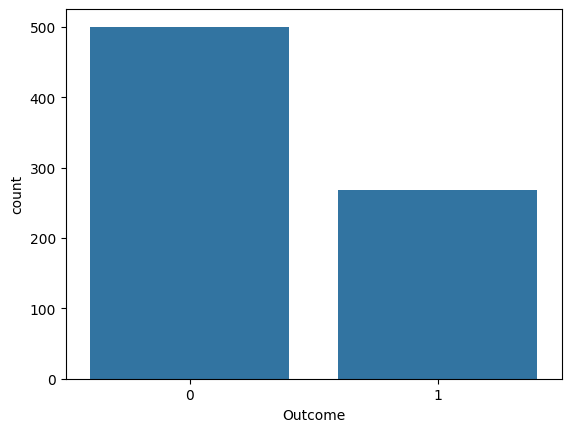

In [31]:
# To Create a bar chart showing how many people in the dataset have diabetes (1) and how many do not (0).
sns.countplot(x='Outcome', data=diabetes_dataset)
plt.show()

Model Performance Metrics (It measure how well the machine learning model predicts diabetes by comparing the predicted results with the actual results)

In [32]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [33]:
# prediction on test data
X_test_prediction = classifier.predict(X_test)

# accuracy score
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)

In [34]:
print("Accuracy on test data :", test_data_accuracy)

Accuracy on test data : 0.7727272727272727


Interpretation:
* Support Vector Machine model correctly predicts diabetes about 77.27% of the
 time on the test dataset.



In [35]:
cm = confusion_matrix(Y_test, X_test_prediction)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[91  9]
 [26 28]]


*   91 patients were correctly predicted as not diabetic ,
*   28 patients were correctly predicted as diabetic
*   9 patients were wrongly predicted as diabetic
*   26 diabetic patients were missed


In [36]:
report = classification_report(Y_test, X_test_prediction)

print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.91      0.84       100
           1       0.76      0.52      0.62        54

    accuracy                           0.77       154
   macro avg       0.77      0.71      0.73       154
weighted avg       0.77      0.77      0.76       154



Visualize confusion matrix

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

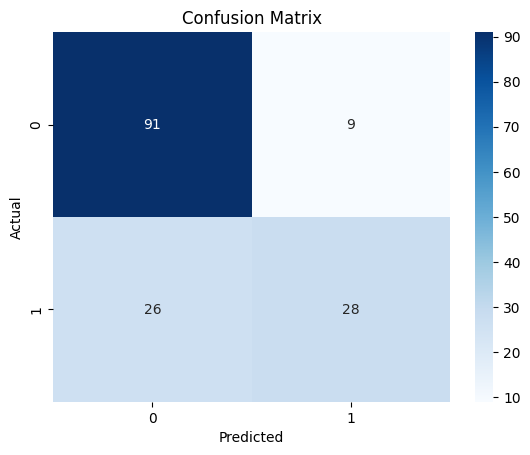

In [39]:
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Using the logistic Regression algorithm

In [41]:
from sklearn.linear_model import LogisticRegression

In [42]:
model = LogisticRegression()

In [45]:
model.fit(X_train, Y_train)

LogisticRegression()

In [46]:
Y_pred = model.predict(X_test)

In [48]:
accuracy = accuracy_score(Y_test, Y_pred)
print("Logistic Regression Accuracy:", accuracy)

Logistic Regression Accuracy: 0.7597402597402597


Interpretation:
* Logistic Regression model correctly predicts diabetes about 75.97% of the time on the test dataset.

In [57]:
# Predict diabetes using Logistic Regression

input_data = (6,148,72,35,0,33.6,0.627,50)

input_array = np.asarray(input_data)
input_array = input_array.reshape(1,-1)

std_data = scaler.transform(input_array)

prediction = model.predict(std_data)

if prediction[0] == 0:
    print("Logistic Regression: diabetic")
else:
    print("Logistic Regression: Non-diabetic")

Logistic Regression: Non-diabetic


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Using random forest algorithm

In [50]:
from sklearn.ensemble import RandomForestClassifier

In [51]:
rf = RandomForestClassifier()
rf.fit(X_train, Y_train)

rf_pred = rf.predict(X_test)

In [52]:
print("Random Forest Accuracy:", accuracy_score(Y_test, rf_pred))

Random Forest Accuracy: 0.7402597402597403


Interpretation:
* Random Forest model correctly predicts diabetes about 74.05% of the time on the test dataset.

In [56]:
# Predict diabetes using Random Forest

prediction_rf = rf.predict(std_data)

if prediction_rf[0] == 0:
    print("Random Forest: diabetic")
else:
    print("Random Forest: Non-diabetic")

Random Forest: Non-diabetic


Model Comparison Chart:-


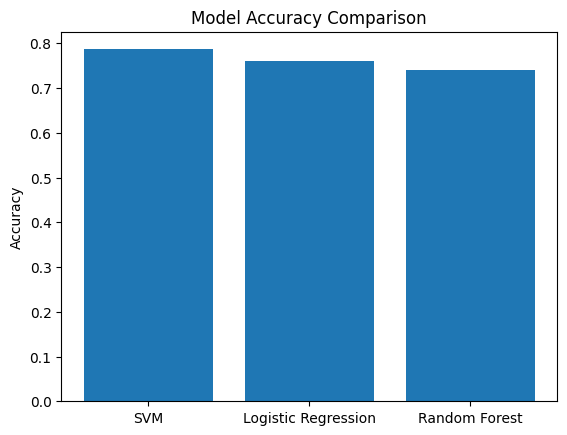

In [59]:
import matplotlib.pyplot as plt

models = ['SVM','Logistic Regression','Random Forest']
accuracy = [0.7866,0.7597,0.7402]

plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()